Mann–Whitney U p-value: 0.37570450207572004


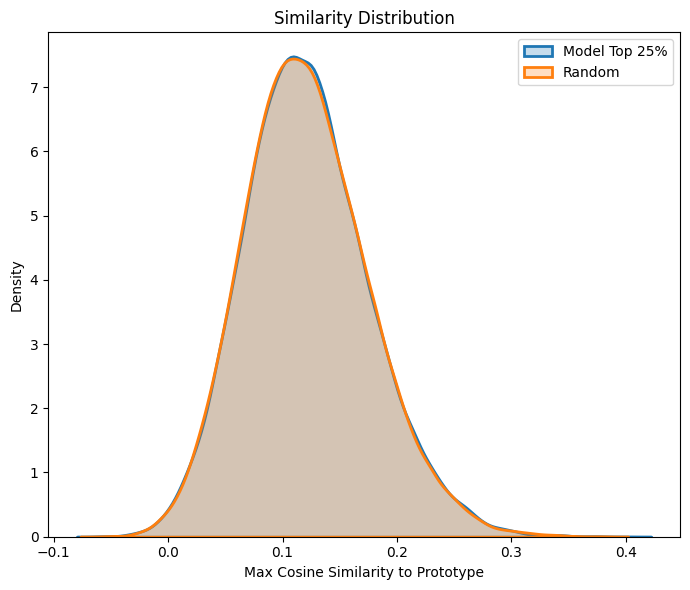

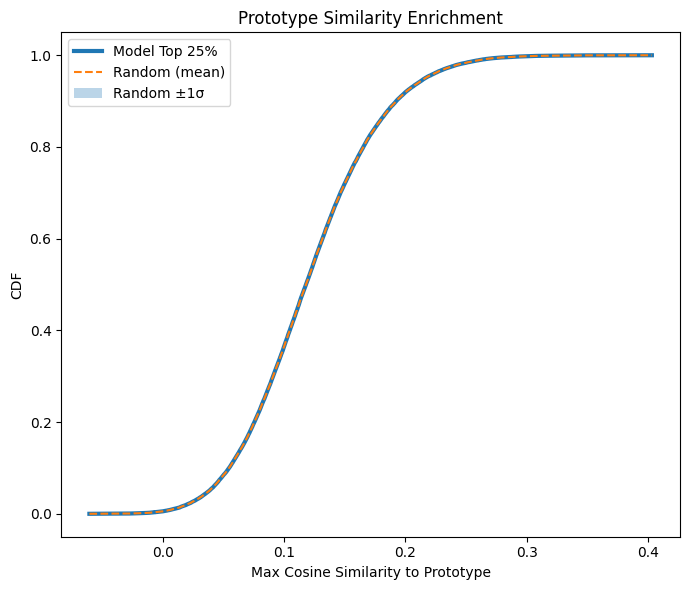

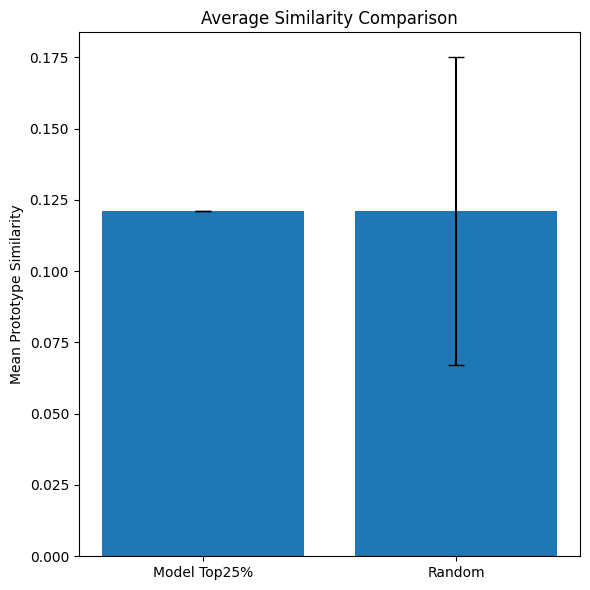

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.stats import mannwhitneyu

# =========================
# 1. 模拟数据（替换为你的数据）
# =========================

np.random.seed(42)

num_molecules = 180000
num_prototypes = 7
dim = 128

candidate_embeddings = np.random.randn(num_molecules, dim)
prototype_embeddings = np.random.randn(num_prototypes, dim)

# 模型评分（例如模型预测概率）
model_scores = np.random.rand(num_molecules)

# =========================
# 2. Normalize embeddings
# =========================

candidate_embeddings = normalize(candidate_embeddings)
prototype_embeddings = normalize(prototype_embeddings)

# =========================
# 3. 计算 similarity
# =========================

sim_matrix = cosine_similarity(candidate_embeddings, prototype_embeddings)

max_similarity = sim_matrix.max(axis=1)

# =========================
# 4. 模型推荐 Top25%
# =========================

top_k = int(0.25 * num_molecules)

top_idx = np.argsort(model_scores)[-top_k:]

sim_top = max_similarity[top_idx]

# =========================
# 5. 多次随机 baseline
# =========================

n_random_trials = 200

random_sims = []

for _ in range(n_random_trials):
    rand_idx = np.random.choice(num_molecules, top_k, replace=False)
    random_sims.append(max_similarity[rand_idx])

random_sims = np.array(random_sims)

# =========================
# 6. 统计显著性
# =========================

stat, p_value = mannwhitneyu(sim_top, random_sims[0])

print("Mann–Whitney U p-value:", p_value)

# =========================
# 7. KDE 分布图
# =========================

plt.figure(figsize=(7,6))

sns.kdeplot(sim_top, label="Model Top 25%", fill=True, linewidth=2)
sns.kdeplot(random_sims[0], label="Random", fill=True, linewidth=2)

plt.xlabel("Max Cosine Similarity to Prototype")
plt.ylabel("Density")
plt.title("Similarity Distribution")
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# 8. CDF enrichment plot（论文最推荐）
# =========================

def compute_cdf(values):

    x = np.sort(values)
    y = np.arange(len(x)) / len(x)

    return x, y

x_model, y_model = compute_cdf(sim_top)

plt.figure(figsize=(7,6))

# model curve
plt.plot(x_model, y_model, label="Model Top 25%", linewidth=3)

# random baseline（均值）
cdf_random = []

for sims in random_sims:

    x, y = compute_cdf(sims)
    cdf_random.append(y)

cdf_random = np.array(cdf_random)

y_mean = cdf_random.mean(axis=0)
y_std = cdf_random.std(axis=0)

plt.plot(x_model, y_mean, label="Random (mean)", linestyle="--")

plt.fill_between(
    x_model,
    y_mean - y_std,
    y_mean + y_std,
    alpha=0.3,
    label="Random ±1σ"
)

plt.xlabel("Max Cosine Similarity to Prototype")
plt.ylabel("CDF")
plt.title("Prototype Similarity Enrichment")

plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Mean comparison bar plot
# =========================

mean_model = sim_top.mean()
mean_random = random_sims.mean()
std_random = random_sims.std()

plt.figure(figsize=(6,6))

plt.bar(
    ["Model Top25%", "Random"],
    [mean_model, mean_random],
    yerr=[0, std_random],
    capsize=6
)

plt.ylabel("Mean Prototype Similarity")

plt.title("Average Similarity Comparison")

plt.tight_layout()
plt.show()

Mann-Whitney U p-value: 0.37570450207572004


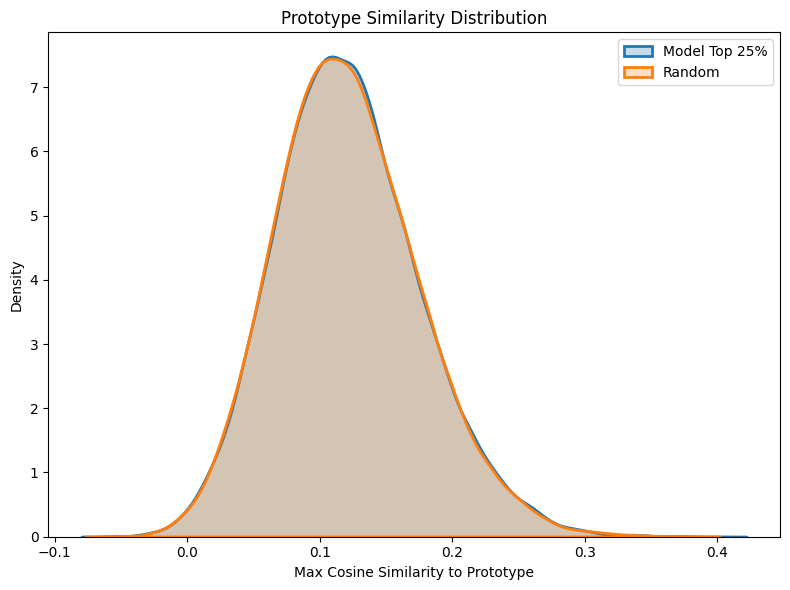

/tmp/ipykernel_3116316/1244342748.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


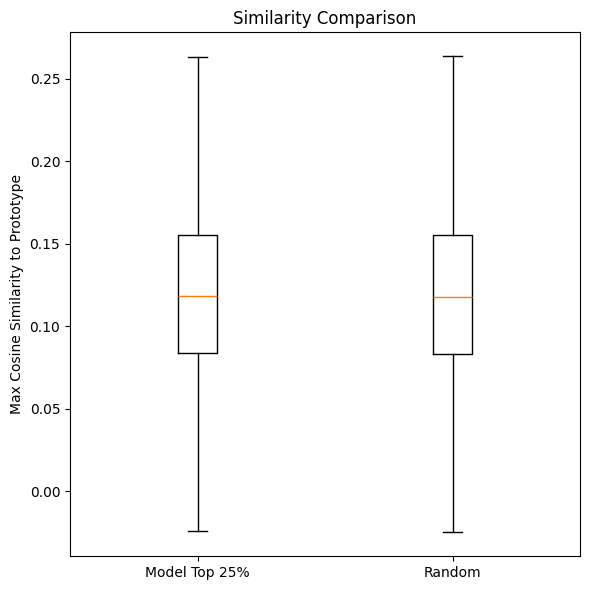

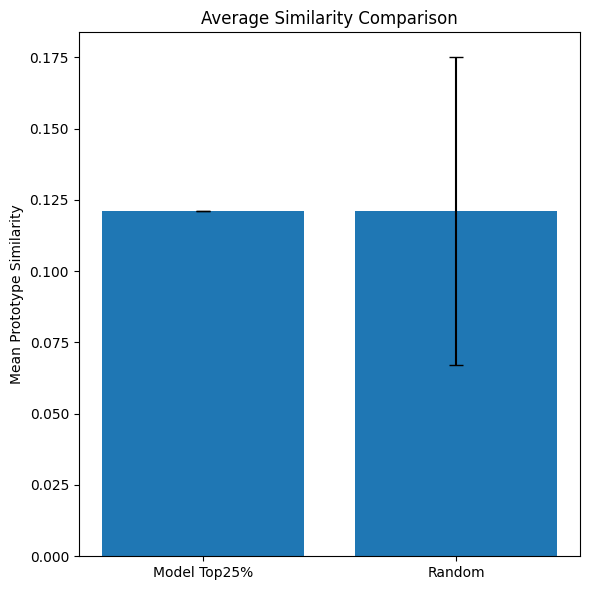

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import mannwhitneyu

# ==============================
# 1. 模拟数据
# ==============================

np.random.seed(42)

num_molecules = 180000
num_prototypes = 7
dim = 128

# 候选分子 embedding
candidate_embeddings = np.random.randn(num_molecules, dim)

# prototype embedding
prototype_embeddings = np.random.randn(num_prototypes, dim)

# 模型对分子的评分（假设）
model_scores = np.random.rand(num_molecules)

# ==============================
# 2. 计算每个分子到prototype的最大相似度
# ==============================

sim_matrix = cosine_similarity(candidate_embeddings, prototype_embeddings)

max_similarity = sim_matrix.max(axis=1)

# ==============================
# 3. 选取模型推荐Top25%
# ==============================

top_k = int(0.25 * num_molecules)

top_indices = np.argsort(model_scores)[-top_k:]

sim_top25 = max_similarity[top_indices]

# ==============================
# 4. 随机抽样（重复多次更稳）
# ==============================

random_sim_all = []

for _ in range(100):
    rand_idx = np.random.choice(num_molecules, top_k, replace=False)
    random_sim_all.append(max_similarity[rand_idx])

random_sim_all = np.array(random_sim_all)

# 取第一次随机样本用于画图
sim_random = random_sim_all[0]

# ==============================
# 5. 统计显著性检验
# ==============================

stat, p_value = mannwhitneyu(sim_top25, sim_random)

print("Mann-Whitney U p-value:", p_value)

# ==============================
# 6. KDE分布图
# ==============================

plt.figure(figsize=(8,6))

sns.kdeplot(sim_top25, label="Model Top 25%", fill=True, linewidth=2)
sns.kdeplot(sim_random, label="Random", fill=True, linewidth=2)

plt.xlabel("Max Cosine Similarity to Prototype")
plt.ylabel("Density")
plt.title("Prototype Similarity Distribution")
plt.legend()

plt.tight_layout()
plt.show()

# ==============================
# 7. 箱线图对比（论文常用）
# ==============================

plt.figure(figsize=(6,6))

data = [sim_top25, sim_random]

plt.boxplot(
    data,
    labels=["Model Top 25%", "Random"],
    showfliers=False
)

plt.ylabel("Max Cosine Similarity to Prototype")
plt.title("Similarity Comparison")

plt.tight_layout()
plt.show()

# ==============================
# 8. 平均值 + 随机误差
# ==============================

mean_model = sim_top25.mean()
mean_random = random_sim_all.mean()
std_random = random_sim_all.std()

plt.figure(figsize=(6,6))

plt.bar(
    ["Model Top25%", "Random"],
    [mean_model, mean_random],
    yerr=[0, std_random],
    capsize=5
)

plt.ylabel("Mean Prototype Similarity")
plt.title("Average Similarity Comparison")

plt.tight_layout()
plt.show()